# Piyu AI Fashion Design Generator — Colab (Final, Clean Build)

**Pipeline:** Text prompt → RealVisXL (SDXL) → SAM mask → IDM-VTON try-on → `final_tryon.png`

Project: https://github.com/Piyu242005/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026
Models: https://huggingface.co/Piyu242005/piyu-fashion-models

**Extra features added:** dependency verification with a pass/fail table that stops *before* expensive inference, resumable/cached downloads (skips work already done), mask preview overlay, before/after result comparison, and a final zip you can download from Colab.

Run cells top to bottom on a **fresh runtime** with a **T4/L4 GPU**.

## STEP 1 — Environment & GPU check

In [13]:
# STEP 1 — Environment & GPU check
import sys, subprocess

print("Python:", sys.version.split()[0])
print("=" * 60)
gpu = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else "❌ No GPU detected. Go to Runtime → Change runtime type → T4/L4 GPU.")


Python: 3.12.13
Sat Aug  8 18:11:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             26W /   70W |    4451MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------------------

## STEP 2 — Controlled dependency installation

Rules followed here (per your instructions):
- Torch/Torchvision are **not** blindly reinstalled — Colab's preinstalled CUDA build is kept and only smoke-tested. It is only touched if the pair is actually broken.
- Every other package is pinned **once**, to a set that is known to work together for this exact pipeline (SDXL + SAM + IDM-VTON). No repeated/contradicting installs later in the notebook.
- Packages your project doesn't actually import (streamlit-webui extras like `gfpgan`, `realesrgan`, `blendmodes`, etc. from the old `requirements.txt`) are skipped — they're not used by `generate_model.py`, `segment.py`, or `try_on.py`, and installing them just adds failure surface.

In [14]:
# STEP 2A — Verify (and only if needed, repair) Torch <-> Torchvision
import subprocess, sys

def sh(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True)

check = sh(f'{sys.executable} -c "import torch, torchvision; from torchvision.ops import nms; '
           f'import torch as t; nms(t.tensor([[0.,0.,1.,1.]]), t.tensor([0.9]), 0.5); '
           f'print(torch.__version__, torchvision.__version__, torch.cuda.is_available())"')

if check.returncode == 0:
    print("✅ Torch/Torchvision are already compatible — leaving them untouched.")
    print(check.stdout.strip())
else:
    print("⚠️ Torch/Torchvision mismatch detected (this is the 'operator torchvision::nms does not exist' error).")
    print("Reinstalling a matched pair for the CUDA build Colab already provides...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "torch", "torchvision"], check=True)
    check2 = sh(f'{sys.executable} -c "import torch, torchvision; from torchvision.ops import nms; '
                f'print(torch.__version__, torchvision.__version__, torch.cuda.is_available())"')
    print(check2.stdout if check2.returncode == 0 else check2.stderr)
    assert check2.returncode == 0, "Torch/Torchvision still broken after reinstall — try Runtime → Disconnect and delete runtime, then restart from Step 1."


✅ Torch/Torchvision are already compatible — leaving them untouched.
2.11.0+cu128 0.26.0+cu128 True


In [15]:
# ============================================================
# STEP 2B — STABLE, PINNED DEPENDENCIES
# SDXL + Auto1111SDK + SAM + IDM-VTON
# ============================================================

import subprocess
import sys

# ------------------------------------------------------------
# 1. Core stack
# ------------------------------------------------------------

CORE_PACKAGES = [
    "numpy==1.26.4",
    "Pillow==10.4.0",
    "opencv-python==4.10.0.84",
    "scipy==1.13.1",

    # Hugging Face / Diffusion
    "diffusers==0.27.2",
    "transformers==4.37.2",
    "accelerate==0.30.1",
    "peft==0.10.0",
    "huggingface_hub==0.23.4",
    "tokenizers==0.15.2",
    "safetensors==0.4.3",

    # ML utilities
    "einops==0.8.0",
    "timm==0.9.16",
    "onnxruntime==1.18.1",
    "ftfy",
    "regex",
    "pycocotools",
    "cloudpickle",
    "av",
    "tqdm",
]

# ------------------------------------------------------------
# 2. Auto1111SDK runtime dependencies
#
# IMPORTANT:
# Python import name:
#     cleanfid
#
# PyPI package name:
#     clean-fid
#
# ------------------------------------------------------------

AUTO1111_PACKAGES = [
    "clean-fid==0.1.35",
    "torchdiffeq==0.2.5",
    "torchsde==0.2.6",
    "jsonmerge",
    "kornia",
    "omegaconf",
    "pytorch-lightning",
    "resize-right",
    "open-clip-torch",
    "inflection",
    "piexif",
    "lark",
    "psutil",
    "scikit-image",
]

# ------------------------------------------------------------
# 3. Install Auto1111SDK itself WITHOUT dependencies
#
# We do this intentionally because its old dependency bounds
# can conflict with the pinned modern Colab stack.
# ------------------------------------------------------------

AUTO1111_SDK = [
    "auto1111sdk==0.0.95"
]

# ------------------------------------------------------------
# 4. Other project dependencies
# ------------------------------------------------------------

OTHER_PACKAGES = [
    "fvcore",
]

# ------------------------------------------------------------
# Installation helper
# ------------------------------------------------------------

def install_packages(packages, no_deps=False):
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--disable-pip-version-check",
    ]

    if no_deps:
        cmd.append("--no-deps")

    cmd.extend(packages)

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        print(result.stdout[-3000:])
        print(result.stderr[-5000:])
        raise RuntimeError(
            "Package installation failed."
        )

    return result


print("=" * 70)
print("INSTALLING CORE PACKAGES")
print("=" * 70)

install_packages(CORE_PACKAGES)

print("\n" + "=" * 70)
print("INSTALLING AUTO1111SDK RUNTIME DEPENDENCIES")
print("=" * 70)

install_packages(AUTO1111_PACKAGES)

print("\n" + "=" * 70)
print("INSTALLING AUTO1111SDK")
print("=" * 70)

install_packages(AUTO1111_SDK, no_deps=True)

print("\n" + "=" * 70)
print("INSTALLING OTHER PROJECT PACKAGES")
print("=" * 70)

install_packages(OTHER_PACKAGES)

print("\n" + "=" * 70)
print("✅ ALL DEPENDENCIES INSTALLED")
print("=" * 70)
print()
print("IMPORTANT:")
print("Runtime → Restart session")
print()
print("After restart, continue from STEP 2C.")

INSTALLING CORE PACKAGES

INSTALLING AUTO1111SDK RUNTIME DEPENDENCIES

INSTALLING AUTO1111SDK

INSTALLING OTHER PROJECT PACKAGES

✅ ALL DEPENDENCIES INSTALLED

IMPORTANT:
Runtime → Restart session

After restart, continue from STEP 2C.


In [16]:
# STEP 2B — Pin the rest of the ML stack (one pass, no re-pins later)
#
# Why these exact versions:
#  - numpy 1.26.4    : last 1.x line, has wheels for every Colab Python build, avoids the
#                       NumPy-2.x ABI break that silently corrupts opencv/diffusers/transformers.
#  - Pillow 10.4.0    : the old repo pin (9.5.0) has no wheel for current Colab Python and is the
#                       actual cause of the PIL._typing / _Ink ImportError. 10.4.0 is modern and stable.
#  - diffusers 0.27.2 : confirmed to expose PositionNet at diffusers.models.embeddings (IDM-VTON's
#                       src/ imports it from exactly that path — newer diffusers moved/renamed it).
#  - transformers 4.37.2, accelerate 0.30.1, peft 0.10.0, tokenizers 0.15.2, safetensors 0.4.3,
#    huggingface_hub 0.23.4 : this exact set is mutually compatible. Accelerate/PEFT drifting apart
#    from Transformers is what causes `clear_device_cache` / `check_fp8_capability` ImportErrors.

import subprocess, sys

# Core pinned stack — this is the part that must resolve exactly, so it's installed
# on its own with full dependency resolution.
core_packages = [
    "torchdiffeq==0.2.5",
    "numpy==1.26.4",
    "Pillow==10.4.0",
    "opencv-python==4.10.0.84",
    "scipy==1.13.1",

    # IDM-VTON
    "diffusers==0.27.2",
    "transformers==4.36.2",
    "accelerate==0.26.1",
    "peft==0.10.0",

    # Hugging Face
    "huggingface_hub==0.23.4",
    "tokenizers==0.15.2",
    "safetensors==0.4.3",

    # ML utilities
    "einops==0.8.0",
    "timm==0.9.16",
    "onnxruntime==1.18.1",
    "torchdiffeq==0.2.5",

    # Other dependencies
    "ftfy",
    "regex",
    "pycocotools",
    "cloudpickle",
    "av",
    "tqdm",
    "jsonmerge",]

# auto1111sdk and fvcore each ship their own (looser/older) dependency bounds that
# directly conflict with diffusers==0.27.2 / Pillow==10.4.0 above — pip's resolver
# reports 'ResolutionImpossible' if these are installed in the same pass as core_packages.
# Installed with --no-deps instead: every runtime dependency they actually import
# (numpy, Pillow, torch, tqdm, etc.) is already satisfied by core_packages, so skipping
# their declared bounds is safe here.
nodeps_packages = [
    "auto1111sdk",                                                    # used by generate_model.py (RealVisXL loader)
    "fvcore",
    "git+https://github.com/facebookresearch/segment-anything.git",  # SAM — pure python, no compile needed
]

print("Installing", len(core_packages), "core packages (this can take a few minutes)...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--no-warn-conflicts"] + core_packages,
    capture_output=True, text=True,
)
print(result.stdout[-3000:])
if result.returncode != 0:
    print("❌ pip reported errors — core install did NOT complete:")
    print(result.stderr[-3000:])
    raise RuntimeError("STEP 2B failed on core_packages. Fix the pip error above and re-run this cell before "
                        "continuing — do NOT proceed to STEP 2C, the pins are not in place yet.")

print("\nInstalling", len(nodeps_packages), "packages with --no-deps (auto1111sdk, fvcore, SAM)...")
result2 = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--no-warn-conflicts", "--no-deps"] + nodeps_packages,
    capture_output=True, text=True,
)
print(result2.stdout[-3000:])
if result2.returncode != 0:
    print("❌ pip reported errors — auto1111sdk/fvcore/SAM install did NOT complete:")
    print(result2.stderr[-3000:])
    raise RuntimeError("STEP 2B failed on nodeps_packages. Fix the pip error above and re-run this cell before "
                        "continuing — do NOT proceed to STEP 2C.")

print("\n✅ Dependency installation completed.")
print("\n⚠️ IMPORTANT — use  Runtime → Restart session  (NOT 'Disconnect and delete runtime').")
print("'Restart session' keeps the packages you just installed and only resets the Python process.")
print("'Disconnect and delete runtime' wipes this install completely and gives you a brand-new,")
print("unpinned environment — that is the #1 cause of the diffusers/numpy version asserts failing")
print("in STEP 2C. After restarting, continue from STEP 2C (do not re-run STEP 2B).")


Installing 23 core packages (this can take a few minutes)...


Installing 3 packages with --no-deps (auto1111sdk, fvcore, SAM)...


✅ Dependency installation completed.

⚠️ IMPORTANT — use  Runtime → Restart session  (NOT 'Disconnect and delete runtime').
'Restart session' keeps the packages you just installed and only resets the Python process.
'Disconnect and delete runtime' wipes this install completely and gives you a brand-new,
unpinned environment — that is the #1 cause of the diffusers/numpy version asserts failing
in STEP 2C. After restarting, continue from STEP 2C (do not re-run STEP 2B).


In [17]:
# STEP 2C — Run this AFTER restarting the runtime, to confirm the pins took effect
import numpy as np, PIL, torch, diffusers, transformers, accelerate

print("NumPy       :", np.__version__)
print("Pillow      :", PIL.__version__)
print("Torch       :", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("Diffusers   :", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate  :", accelerate.__version__)

expected = {"NumPy": (np.__version__, "1.26.4"), "Pillow": (PIL.__version__, "10.4.0"),
            "Diffusers": (diffusers.__version__, "0.27.2")}
wrong = {name: got for name, (got, want) in expected.items() if got != want}

if wrong:
    print("\n❌ Pinned versions from STEP 2B are NOT active in this runtime:")
    for name, got in wrong.items():
        print(f"   {name}: got {got}, expected {expected[name][1]}")
    print("\nThis almost always means one of two things:")
    print("  1) You used Runtime → Disconnect and delete runtime (wipes all installs) instead of")
    print("     Runtime → Restart session (keeps installs, only resets the Python process).")
    print("  2) STEP 2B was never actually run/completed in this runtime before this cell.")
    print("\nFix: go back and run STEP 2A then STEP 2B, wait for '✅ Dependency installation completed.',")
    print("then use Runtime → Restart session (NOT delete runtime), then re-run this cell (STEP 2C).")
    raise AssertionError("Pinned versions missing — see diagnosis above. Do not continue to STEP 3 yet.")

print("\n✅ Core stack confirmed after restart.")


NumPy       : 2.2.6
Pillow      : 10.4.0
Torch       : 2.11.0+cu128 | CUDA: True
Diffusers   : 0.27.2
Transformers: 4.37.2
Accelerate  : 0.30.1

❌ Pinned versions from STEP 2B are NOT active in this runtime:
   NumPy: got 2.2.6, expected 1.26.4

This almost always means one of two things:
  1) You used Runtime → Disconnect and delete runtime (wipes all installs) instead of
     Runtime → Restart session (keeps installs, only resets the Python process).
  2) STEP 2B was never actually run/completed in this runtime before this cell.

Fix: go back and run STEP 2A then STEP 2B, wait for '✅ Dependency installation completed.',
then use Runtime → Restart session (NOT delete runtime), then re-run this cell (STEP 2C).


AssertionError: Pinned versions missing — see diagnosis above. Do not continue to STEP 3 yet.

## STEP 3 — Install Detectron2 (needed for DensePose in IDM-VTON)

In [18]:
# STEP 3 — Detectron2
#
# Detectron2 has no prebuilt wheel that reliably matches every Colab Torch build, so it's
# built from source. This is the slowest install step (~5-10 min) but only needs to run once
# per runtime. Skipped automatically if already importable.
import subprocess, sys

try:
    import detectron2
    print("✅ Detectron2 already installed:", detectron2.__version__)
except ImportError:
    print("Installing Detectron2 from source (~5-10 min)...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/facebookresearch/detectron2.git"],
        capture_output=True, text=True,
    )
    print(result.stdout[-2000:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError("Detectron2 install failed — see error above.")
    import detectron2
    print("✅ Detectron2 installed:", detectron2.__version__)


✅ Detectron2 already installed: 0.6


In [21]:
# STEP 3B — DensePose (separate from base Detectron2)
import subprocess, sys
try:
    import densepose
    print("✅ densepose already installed")
except ImportError:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/facebookresearch/detectron2.git@main#subdirectory=projects/DensePose"],
        capture_output=True, text=True,
    )
    print(result.stdout[-2000:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError("DensePose install failed — see error above.")
    import densepose
    print("✅ densepose installed")

✅ densepose already installed


## STEP 4 — Clone the project

In [22]:
# STEP 4 — Clone project (correct URL — the old notebook had a typo here)
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/Piyu242005/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026.git"
REPO_ROOT = Path("/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026")
PROJECT = REPO_ROOT / "Piyu-AI-Clothing-Fashion-Design-Generator"

if not REPO_ROOT.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
else:
    print("Repo already cloned, pulling latest...")
    subprocess.run(["git", "-C", str(REPO_ROOT), "pull"], check=False)

assert PROJECT.exists(), f"Expected project folder missing: {PROJECT}"
print("✅ PROJECT:", PROJECT)


Repo already cloned, pulling latest...
✅ PROJECT: /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator


## STEP 5 — IDM-VTON source setup

This is the step that fixes `ModuleNotFoundError: No module named 'src'`. IDM-VTON is cloned,
then **your own `try_on.py` is copied into it** (exactly as your README specifies), because
`try_on.py` uses relative imports (`from src...`, `import apply_net`, `import utils_mask`) that
only resolve when it sits next to IDM-VTON's `src/` folder.

In [23]:
print(type(PROJECT), PROJECT)

<class 'pathlib.PosixPath'> /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator


In [24]:
import subprocess
print(subprocess.run(["ls", "/content"], capture_output=True, text=True).stdout)

ai-clothing-fashion-design-generator
AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026
AI-Fashion-Design-Generator-IBM-INTERSHIP-2026
_compat_shims
sample_data



In [25]:
import subprocess
print(subprocess.run(["find", str(PROJECT), "-iname", "*realvisxl*", "-o", "-iname", "*sam_vit*"],
                      capture_output=True, text=True).stdout)

/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/.huggingface/download/realvisxl
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/.huggingface/download/realvisxl/realvisxl.safetensors.lock
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/models/.huggingface/download/realvisxl
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/models/.huggingface/download/realvisxl/realvisxl.safetensors.lock
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/models/realvisxl
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/realvisxl
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/weights/realvisxl.safetensors
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-

In [26]:
REPO_URL = "https://github.com/Piyu242005/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026.git"
REPO_ROOT = Path("/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026")
PROJECT = REPO_ROOT / "Piyu-AI-Clothing-Fashion-Design-Generator"

In [27]:
from huggingface_hub import hf_hub_download
import shutil

WEIGHTS_DIR = PROJECT / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
REPO_ID = "Piyu2420/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026"  # confirm this is right

for repo_filename, target_name in [
    ("realvisxl/realvisxl.safetensors", "realvisxl.safetensors"),
    ("sam/sam_vit_h_4b8939.pth", "sam_vit_h_4b8939.pth"),
]:
    cached = hf_hub_download(repo_id=REPO_ID, filename=repo_filename)
    shutil.copy2(cached, WEIGHTS_DIR / target_name)
    print("✅", target_name)

✅ realvisxl.safetensors
✅ sam_vit_h_4b8939.pth


In [28]:
# STEP 5 — Clone IDM-VTON + copy try_on.py into it
from pathlib import Path
import subprocess, shutil

PROJECT = Path(PROJECT)          # <-- coerce, in case it got reset to a str upstream
IDM = PROJECT / "idm_vton"

if not IDM.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/yisol/IDM-VTON.git", str(IDM)],
        check=True,
    )
else:
    print("idm_vton/ already exists, skipping clone.")

assert (IDM / "src").exists(), f"❌ IDM-VTON src folder missing: {IDM / 'src'}"

shutil.copy2(PROJECT / "try_on.py", IDM / "try_on.py")
shutil.copy2(IDM / "gradio_demo" / "utils_mask.py", IDM / "utils_mask.py")
shutil.copy2(IDM / "gradio_demo" / "apply_net.py", IDM / "apply_net.py")

print("✅ IDM-VTON ready at:", IDM)
print("✅ try_on.py copied into idm_vton/")

idm_vton/ already exists, skipping clone.
✅ IDM-VTON ready at: /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton
✅ try_on.py copied into idm_vton/


## STEP 6 — Hugging Face authentication (optional)

Your models live in the public repo `Piyu242005/piyu-fashion-models`. If it's public, this step
does nothing and downloads proceed anonymously. Only fill in a token if you've made the repo
private, or if `yisol/idm_vton` ever requires auth.

In [29]:
# STEP 6 — Optional Hugging Face login
import os
from huggingface_hub import HfApi

HF_TOKEN = os.environ.get("HF_TOKEN", "")  # or set via Colab Secrets and load into os.environ

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    print("✅ Logged in as:", HfApi().whoami()["name"])
else:
    print("No HF_TOKEN set — proceeding anonymously (fine for public repos).")


No HF_TOKEN set — proceeding anonymously (fine for public repos).


## STEP 7 — Download / verify model weights

Nothing custom to build here — your `model_manager.py` already handles caching correctly via
`hf_hub_download()`, which skips re-downloading anything already present. This just calls it.

In [30]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN:
    print("✅ HF_TOKEN found")
    print("Token length:", len(HF_TOKEN))
else:
    print("❌ HF_TOKEN not found")

✅ HF_TOKEN found
Token length: 37


In [31]:
from huggingface_hub import login, whoami

login(token=HF_TOKEN, add_to_git_credential=False)

info = whoami(token=HF_TOKEN)

print("✅ Hugging Face authentication successful")
print("Username:", info["name"])

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /root/.cache/huggingface/token
Login successful
✅ Hugging Face authentication successful
Username: Piyu2420


In [32]:
from huggingface_hub import HfApi
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

api = HfApi(token=HF_TOKEN)

# Check your account
me = api.whoami()

print("✅ Logged in as:", me["name"])

print("\nSearching your model repositories...\n")

repos = list(api.list_models(author=me["name"]))

for repo in repos:
    print(repo.id)

✅ Logged in as: Piyu2420

Searching your model repositories...

Piyu2420/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026
Piyu2420/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026


In [33]:
%cd /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator

/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator


In [34]:
from huggingface_hub import login

login()

In [35]:
# ============================================================
# FINAL IDM-VTON — VERIFY ALL 9 MODELS
# ============================================================

from pathlib import Path

PROJECT = Path(
    "/content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/"
    "Piyu-AI-Clothing-Fashion-Design-Generator"
)

MODELS = {
    "RealVisXL":
        PROJECT / "weights/realvisxl.safetensors",

    "SAM":
        PROJECT / "weights/sam_vit_h_4b8939.pth",

    "DensePose":
        PROJECT / "idm_vton/ckpt/densepose/model_final_162be9.pkl",

    "Human Parsing ATR":
        PROJECT / "idm_vton/ckpt/humanparsing/parsing_atr.onnx",

    "Human Parsing LIP":
        PROJECT / "idm_vton/ckpt/humanparsing/parsing_lip.onnx",

    "OpenPose":
        PROJECT / "idm_vton/ckpt/openpose/ckpts/body_pose_model.pth",

    "Image Encoder Config":
        PROJECT / "idm_vton/ckpt/image_encoder/config.json",

    "Image Encoder":
        PROJECT / "idm_vton/ckpt/image_encoder/model.safetensors",

    "IP-Adapter":
        PROJECT / "idm_vton/ckpt/ip_adapter/ip-adapter-plus_sdxl_vit-h.bin",
}


print("=" * 80)
print("           IDM-VTON MODEL VERIFICATION")
print("=" * 80)

passed = 0
failed = 0

for name, path in MODELS.items():

    if path.exists() and path.is_file() and path.stat().st_size > 0:

        size_mb = path.stat().st_size / (1024 ** 2)

        print(f"✅ {name:<25} {size_mb:>10.2f} MB")
        print(f"   {path}")

        passed += 1

    else:

        print(f"❌ {name:<25} MISSING")
        print(f"   {path}")

        failed += 1

    print("-" * 80)


print("=" * 80)
print(f"PASSED : {passed}/9")
print(f"FAILED : {failed}/9")
print("=" * 80)


if passed == 9:

    print("\n🎉 ALL 9 REQUIRED MODELS ARE DOWNLOADED!")
    print("🎉 ALL IDM-VTON WEIGHTS ARE PRESENT LOCALLY!")
    print("\n✅ You can proceed to the IDM-VTON pipeline.")

else:

    print("\n⚠️ SOME MODELS ARE STILL MISSING.")
    print("Check the ❌ entries above.")

           IDM-VTON MODEL VERIFICATION
✅ RealVisXL                    6617.76 MB
   /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/weights/realvisxl.safetensors
--------------------------------------------------------------------------------
✅ SAM                          2445.75 MB
   /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/weights/sam_vit_h_4b8939.pth
--------------------------------------------------------------------------------
✅ DensePose                     243.91 MB
   /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/ckpt/densepose/model_final_162be9.pkl
--------------------------------------------------------------------------------
✅ Human Parsing ATR             254.50 MB
   /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/ckpt/humanparsing/parsing_a

In [36]:
# Direct download of the 6 missing model files
import shutil
from pathlib import Path
from huggingface_hub import hf_hub_download
import requests
from tqdm import tqdm

WEIGHTS_DIR = PROJECT / "weights"
CKPT_DIR = IDM / "ckpt"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

REPO_ID = "Piyu2420/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026"

def fetch(repo_filename, target_path: Path):
    target_path.parent.mkdir(parents=True, exist_ok=True)
    if target_path.exists() and target_path.stat().st_size > 1_000_000:
        print(f"✅ already present: {target_path}")
        return
    print(f"⬇️  {repo_filename} -> {target_path}")
    cached = hf_hub_download(repo_id=REPO_ID, filename=repo_filename)
    shutil.copy2(cached, target_path)
    print(f"✅ saved {target_path} ({target_path.stat().st_size / 1e6:.1f} MB)")

def fetch_url(url, target_path: Path):
    target_path.parent.mkdir(parents=True, exist_ok=True)
    if target_path.exists() and target_path.stat().st_size > 1_000_000:
        print(f"✅ already present: {target_path}")
        return
    print(f"⬇️  {url} -> {target_path}")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(target_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
                bar.update(len(chunk))
    print(f"✅ saved {target_path} ({target_path.stat().st_size / 1e6:.1f} MB)")

# RealVisXL and SAM live flat in the HF repo, but your scripts expect them under weights/
fetch("realvisxl/realvisxl.safetensors", WEIGHTS_DIR / "realvisxl.safetensors")
fetch("sam/sam_vit_h_4b8939.pth", WEIGHTS_DIR / "sam_vit_h_4b8939.pth")

# Human parsing + openpose — fine in your HF repo, just need moving to the ckpt/ layout
fetch("idm_vton/humanparsing/parsing_atr.onnx", CKPT_DIR / "humanparsing" / "parsing_atr.onnx")
fetch("idm_vton/humanparsing/parsing_lip.onnx", CKPT_DIR / "humanparsing" / "parsing_lip.onnx")
fetch("idm_vton/openpose/body_pose_model.pth", CKPT_DIR / "openpose" / "ckpts" / "body_pose_model.pth")

# DensePose: your HF repo's copy is broken (31 bytes) — pull the real ~230MB file from
# IDM-VTON's own official Space instead.
fetch_url(
    "https://huggingface.co/spaces/yisol/IDM-VTON/resolve/main/ckpt/densepose/model_final_162be9.pkl?download=true",
    CKPT_DIR / "densepose" / "model_final_162be9.pkl",
)

print("\n✅ Done. Re-run your verification cell to confirm all 6 now show OK.")

✅ already present: /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/weights/realvisxl.safetensors
✅ already present: /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/weights/sam_vit_h_4b8939.pth
✅ already present: /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/ckpt/humanparsing/parsing_atr.onnx
✅ already present: /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/ckpt/humanparsing/parsing_lip.onnx
✅ already present: /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/ckpt/openpose/ckpts/body_pose_model.pth
✅ already present: /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/ckpt/densepose/model_final_162be9.pkl

✅ Done. Re-run your verification cell to confirm all

In [37]:
from pathlib import Path

PROJECT = Path(
    "/content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/"
    "Piyu-AI-Clothing-Fashion-Design-Generator"
)

files = [
    "weights/realvisxl.safetensors",
    "weights/sam_vit_h_4b8939.pth",
    "idm_vton/ckpt/densepose/model_final_162be9.pkl",
    "idm_vton/ckpt/humanparsing/parsing_atr.onnx",
    "idm_vton/ckpt/humanparsing/parsing_lip.onnx",
    "idm_vton/ckpt/openpose/ckpts/body_pose_model.pth",
    "idm_vton/ckpt/image_encoder/config.json",
    "idm_vton/ckpt/image_encoder/model.safetensors",
    "idm_vton/ckpt/ip_adapter/ip-adapter-plus_sdxl_vit-h.bin",
]

for f in files:
    p = PROJECT / f

    if p.exists():
        size_mb = p.stat().st_size / (1024 ** 2)
        print(f"{'✅' if size_mb > 1 else '⚠️'} {size_mb:,.2f} MB — {f}")
    else:
        print(f"❌ MISSING — {f}")

✅ 6,617.76 MB — weights/realvisxl.safetensors
✅ 2,445.75 MB — weights/sam_vit_h_4b8939.pth
✅ 243.91 MB — idm_vton/ckpt/densepose/model_final_162be9.pkl
✅ 254.50 MB — idm_vton/ckpt/humanparsing/parsing_atr.onnx
✅ 254.50 MB — idm_vton/ckpt/humanparsing/parsing_lip.onnx
✅ 199.57 MB — idm_vton/ckpt/openpose/ckpts/body_pose_model.pth
⚠️ 0.00 MB — idm_vton/ckpt/image_encoder/config.json
✅ 2,411.24 MB — idm_vton/ckpt/image_encoder/model.safetensors
✅ 966.51 MB — idm_vton/ckpt/ip_adapter/ip-adapter-plus_sdxl_vit-h.bin


In [38]:
# ============================================================
# FIX — Complete auto1111sdk dependencies
# ============================================================

import subprocess
import sys

packages = [
    "torchdiffeq==0.2.5",
    "jsonmerge",
    "omegaconf",
    "kornia",
    "pytorch-lightning",
]

print("Installing missing auto1111sdk runtime dependencies...")

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--no-deps",
        *packages
    ],
    capture_output=True,
    text=True
)

print(result.stdout[-2000:])

if result.returncode != 0:
    print(result.stderr[-3000:])
    raise RuntimeError("Dependency installation failed.")

# Verify the exact problematic dependency
test = subprocess.run(
    [
        sys.executable,
        "-c",
        "import torchdiffeq; print('torchdiffeq:', torchdiffeq.__version__)"
    ],
    capture_output=True,
    text=True
)

if test.returncode != 0:
    print(test.stderr)
    raise RuntimeError("torchdiffeq is still unavailable.")

print(test.stdout)

print("✅ auto1111sdk dependency repair completed.")

Installing missing auto1111sdk runtime dependencies...

torchdiffeq: 0.2.5

✅ auto1111sdk dependency repair completed.


In [43]:
# STEP 7 — Download model weights via your existing model_manager.py
import subprocess, sys

os.chdir(PROJECT)
result = subprocess.run(
    [sys.executable, "-c",
     "from model_manager import download_all_models; p = download_all_models(); "
     "print('\\n'.join(f'{k}: {v}' for k, v in p.__dict__.items()))"],
    cwd=str(PROJECT), capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr[-3000:])
    raise RuntimeError("Model download failed — check the HF repo/token above.")
print("✅ RealVisXL, SAM, DensePose, and human-parsing weights are cached in PROJECT/models/.")



Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'model_manager'



RuntimeError: Model download failed — check the HF repo/token above.

## STEP 8 — Dependency verification (before any expensive inference)

Every import IDM-VTON, SAM, and the rest of the pipeline actually needs, checked in one place.
If anything fails, it prints exactly what and stops here — before you burn GPU minutes.

In [41]:
# STEP 2D — Fix onnxruntime capi conflict (two variants installed simultaneously)
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y",
                "onnxruntime", "onnxruntime-gpu"], capture_output=True, text=True)

result = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnxruntime==1.18.1"],
                         capture_output=True, text=True)
print(result.stdout[-1000:])
if result.returncode != 0:
    print(result.stderr[-2000:])
    raise RuntimeError("onnxruntime reinstall failed.")

check = subprocess.run([sys.executable, "-c", "import onnxruntime; print(onnxruntime.__version__)"],
                        capture_output=True, text=True)
print(check.stdout if check.returncode == 0 else check.stderr)


1.18.1



In [44]:
# Run once, after cloning IDM-VTON, before Step 8
import re
from pathlib import Path

for fname in ["unet_hacked_garmnet.py", "unet_hacked_tryon.py"]:
    fpath = IDM / "src" / fname
    text = fpath.read_text()
    if "PositionNet" in text and "GLIGENTextBoundingboxProjection" not in text:
        patched = text.replace(
            "from diffusers.models.embeddings import (",
            "from diffusers.models.embeddings import GLIGENTextBoundingboxProjection as PositionNet\n"
            "from diffusers.models.embeddings import (",
        )
        # remove PositionNet from the original import list to avoid a duplicate/conflicting import
        patched = re.sub(r"\bPositionNet,?\s*", "", patched, count=1)
        fpath.write_text(patched)
        print(f"✅ patched {fname}")
    else:
        print(f"⏭️  {fname} unchanged (already patched or doesn't need it)")

✅ patched unet_hacked_garmnet.py
✅ patched unet_hacked_tryon.py


In [45]:
print("IDM:", IDM)
print("IDM exists?", IDM.exists())
print("IDM/src exists?", (IDM / "src").exists())
print("IDM/try_on.py exists?", (IDM / "try_on.py").exists())
print("IDM/utils_mask.py exists?", (IDM / "utils_mask.py").exists())
print("IDM/apply_net.py exists?", (IDM / "apply_net.py").exists())
print()
print("PROJECT:", PROJECT)
print("PROJECT exists?", PROJECT.exists())

IDM: /content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton
IDM exists? True
IDM/src exists? True
IDM/try_on.py exists? True
IDM/utils_mask.py exists? True
IDM/apply_net.py exists? True

PROJECT: /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator
PROJECT exists? True


In [46]:
IDM = PROJECT / "idm_vton"

In [47]:
import subprocess
result = subprocess.run(
    ["find", "/content", "-name", "unet_hacked_garmnet.py", "-o", "-name", "try_on.py"],
    capture_output=True, text=True
)
print(result.stdout)

/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/try_on.py
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/idm_vton/src/unet_hacked_garmnet.py
/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator/try_on.py



In [48]:
from pathlib import Path

# Fix both variables to the correct spelling — INTERSHIP (your actual GitHub repo URL)
PROJECT = Path("/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator")
IDM = PROJECT / "idm_vton"

print("PROJECT exists?", PROJECT.exists())
print("IDM exists?", IDM.exists())
print("IDM/src exists?", (IDM / "src").exists())

PROJECT exists? True
IDM exists? True
IDM/src exists? True


In [49]:
# Compatibility shim: torch.utils._pytree._register_pytree_node
#
# diffusers==0.25.0 / transformers==4.36.2 still call the *private*
# torch.utils._pytree._register_pytree_node API. Colab's current Torch build has
# dropped/changed that private function, which crashes anything that imports
# src.tryon_pipeline (Step 8, Step 15, Step 16 all do this in a NEW subprocess).
#
# This writes a sitecustomize.py shim and puts it on PYTHONPATH so every
# `sys.executable ...` subprocess this notebook launches picks it up automatically.

import os
import sys
from pathlib import Path

SITECUSTOMIZE_DIR = Path("/content/_compat_shims")
SITECUSTOMIZE_DIR.mkdir(exist_ok=True)

(SITECUSTOMIZE_DIR / "sitecustomize.py").write_text('''
import torch.utils._pytree as _pytree

def _compat_register_pytree_node(cls, flatten_fn, unflatten_fn, *args, **kwargs):
    if hasattr(_pytree, "register_pytree_node"):
        kwargs.setdefault(
            "serialized_type_name", f"{cls.__module__}.{cls.__qualname__}"
        )
        return _pytree.register_pytree_node(cls, flatten_fn, unflatten_fn, **kwargs)
    return _pytree._orig_register_pytree_node(cls, flatten_fn, unflatten_fn)

if hasattr(_pytree, "register_pytree_node"):
    if hasattr(_pytree, "_register_pytree_node") and not hasattr(
        _pytree, "_orig_register_pytree_node"
    ):
        _pytree._orig_register_pytree_node = _pytree._register_pytree_node
    _pytree._register_pytree_node = _compat_register_pytree_node
''')

os.environ["PYTHONPATH"] = f"{SITECUSTOMIZE_DIR}:{os.environ.get('PYTHONPATH', '')}"
sys.path.insert(0, str(SITECUSTOMIZE_DIR))
import sitecustomize  # noqa: F401,E402

# Prove the shim actually works, in a subprocess just like Step 8 uses:
import subprocess
test = subprocess.run(
    [sys.executable, "-c",
     "from src.tryon_pipeline import StableDiffusionXLInpaintPipeline; print('OK')"],
    cwd=str(IDM), capture_output=True, text=True,
)
print(test.stdout or test.stderr[-1500:])

OK



In [50]:
import subprocess
from pathlib import Path

for fname in ["src/unet_hacked_garmnet.py", "src/unet_hacked_tryon.py"]:
    result = subprocess.run(
        ["git", "checkout", "--", fname], cwd=str(IDM), capture_output=True, text=True
    )
    print(fname, "git checkout rc:", result.returncode, result.stderr.strip())

for fname in ["unet_hacked_garmnet.py", "unet_hacked_tryon.py"]:
    fpath = IDM / "src" / fname
    text = fpath.read_text()
    still_bad = "GLIGENTextBoundingboxProjection" in text
    print(fname, "-> still corrupted after checkout:", still_bad)

    if still_bad:
        # git checkout didn't take effect (e.g. file isn't clean-tracked) — repair directly.
        fixed = text.replace(
            "from diffusers.models.embeddings import GLIGENTextBoundingboxProjection as "
            "from diffusers.models.embeddings import (",
            "from diffusers.models.embeddings import (",
        )
        if fixed != text:
            fpath.write_text(fixed)
            print(f"  repaired {fname} directly")
        else:
            print(f"  WARNING: {fname} has an unrecognized corruption pattern — paste its "
                  f"content around 'GLIGENTextBoundingboxProjection' here so I can check it")

# Sanity check: file should be syntactically valid now
import ast
for fname in ["unet_hacked_garmnet.py", "unet_hacked_tryon.py"]:
    fpath = IDM / "src" / fname
    try:
        ast.parse(fpath.read_text())
        print(fname, "-> syntax OK")
    except SyntaxError as e:
        print(fname, "-> STILL BROKEN:", e)

src/unet_hacked_garmnet.py git checkout rc: 0 
src/unet_hacked_tryon.py git checkout rc: 0 
unet_hacked_garmnet.py -> still corrupted after checkout: False
unet_hacked_tryon.py -> still corrupted after checkout: False
unet_hacked_garmnet.py -> syntax OK
unet_hacked_tryon.py -> syntax OK


In [52]:
# ============================================================
# IDM-VTON CHECK — SKIP FOR NOW
# ============================================================

SKIP_IDM_VTON = True

if SKIP_IDM_VTON:
    print("⏭️ IDM-VTON check skipped.")
    print("✅ Continuing with fashion model generation.")
else:
    # Existing IDM-VTON verification code here
    pass

⏭️ IDM-VTON check skipped.
✅ Continuing with fashion model generation.


In [53]:
# STEP 8 — Full dependency verification
import sys, subprocess
from pathlib import Path

results = []

def check(name, fn):
    try:
        fn()
        results.append((name, True, ""))
    except Exception as e:
        results.append((name, False, str(e)))

def imp(mod):
    return lambda: __import__(mod)

check("Python >= 3.10", lambda: (_ for _ in ()).throw(AssertionError) if sys.version_info < (3, 10) else None)
check("NumPy", imp("numpy"))
check("Pillow", imp("PIL"))
check("Torch", imp("torch"))
check("Torchvision", imp("torchvision"))

def cuda_check():
    import torch
    assert torch.cuda.is_available(), "CUDA not available"
check("CUDA available", cuda_check)

def nms_check():
    import torch
    from torchvision.ops import nms
    nms(torch.tensor([[0., 0., 1., 1.]]), torch.tensor([0.9]), 0.5)
check("Torch<->Torchvision ops (nms)", nms_check)

check("Diffusers", imp("diffusers"))

def positionnet_check():
    from diffusers.models import embeddings
    assert hasattr(embeddings, "PositionNet") or hasattr(embeddings, "GLIGENTextBoundingboxProjection"), \
        "Neither PositionNet nor GLIGENTextBoundingboxProjection found in diffusers.models.embeddings"
check("Diffusers PositionNet", positionnet_check)

check("Transformers", imp("transformers"))

def clip_check():
    from transformers import CLIPImageProcessor, CLIPVisionModelWithProjection, CLIPTextModelWithProjection
check("Transformers CLIP classes", clip_check)

check("Accelerate", imp("accelerate"))
check("PEFT", imp("peft"))
check("Hugging Face Hub", imp("huggingface_hub"))
check("Detectron2", imp("detectron2"))

def sam_check():
    from segment_anything import SamPredictor, sam_model_registry
check("Segment Anything import", sam_check)

def idm_src_check():
    idm_test = subprocess.run(
        [sys.executable, "-c",
         "from src.tryon_pipeline import StableDiffusionXLInpaintPipeline; "
         "from src.unet_hacked_garmnet import UNet2DConditionModel; "
         "print('ok')"],
        cwd=str(IDM), capture_output=True, text=True,
    )
    if idm_test.returncode != 0:
        raise RuntimeError(f"Subprocess Error: {idm_test.stderr}")
check("IDM-VTON src/ (TryonPipeline, GarmNet, hacked UNet)", idm_src_check)

def idm_support_check():
    idm_test = subprocess.run(
        [sys.executable, "-c",
         "import utils_mask, apply_net; "
         "from preprocess.humanparsing.run_parsing import Parsing; "
         "from preprocess.openpose.run_openpose import OpenPose; "
         "print('ok')"],
        cwd=str(IDM), capture_output=True, text=True,
    )
    if idm_test.returncode != 0:
        raise RuntimeError(f"Subprocess Error: {idm_test.stderr}")
check("IDM-VTON support modules (utils_mask, apply_net, preprocess)", idm_support_check)

check("try_on.py copied into idm_vton/", lambda: (_ for _ in ()).throw(AssertionError("missing")) if not (IDM / "try_on.py").exists() else None)
def weights_check():
    required = ["weights/realvisxl.safetensors", "weights/sam_vit_h_4b8939.pth",
                "idm_vton/ckpt/densepose/model_final_162be9.pkl",
                "idm_vton/ckpt/humanparsing/parsing_atr.onnx",
                "idm_vton/ckpt/humanparsing/parsing_lip.onnx",
                "idm_vton/ckpt/openpose/ckpts/body_pose_model.pth"]
    missing = [f for f in required if not (PROJECT / f).exists()]
    assert not missing, f"Missing: {missing}"
check("Downloaded model weight files present", weights_check)

print(f"{'CHECK':55} STATUS")
print("-" * 75)
all_ok = True
for name, ok, err in results:
    status = "✅ PASS" if ok else "❌ FAIL"
    print(f"{name:55} {status}")
    if not ok:
        all_ok = False
        print(f"    → {err}")

if not all_ok:
    raise RuntimeError("❌ Verification failed. See the table above.")

CHECK                                                   STATUS
---------------------------------------------------------------------------
Python >= 3.10                                          ✅ PASS
NumPy                                                   ✅ PASS
Pillow                                                  ✅ PASS
Torch                                                   ✅ PASS
Torchvision                                             ✅ PASS
CUDA available                                          ✅ PASS
Torch<->Torchvision ops (nms)                           ✅ PASS
Diffusers                                               ✅ PASS
Diffusers PositionNet                                   ✅ PASS
Transformers                                            ✅ PASS
Transformers CLIP classes                               ✅ PASS
Accelerate                                              ✅ PASS
PEFT                                                    ✅ PASS
Hugging Face Hub                          

RuntimeError: ❌ Verification failed. See the table above.

## STEP 9 — Generate the AI fashion model (RealVisXL)

In [55]:
!git clone https://github.com/Piyu242005/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026.git /content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026

fatal: destination path '/content/AI-Fashion-Design-Generator-IBM-INTERNSHIP-2026' already exists and is not an empty directory.


In [54]:
from pathlib import Path
import sys
import importlib.util

# Folder that contains generate_model.py
PROJECT = Path("/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator")

# Full file path
GENERATE_MODEL = PROJECT / "generate_model.py"

if not GENERATE_MODEL.exists():
    raise FileNotFoundError(f"generate_model.py not found:\n{GENERATE_MODEL}")

# Make project importable
sys.path.insert(0, str(PROJECT))

# Import the file
spec = importlib.util.spec_from_file_location("generate_model", str(GENERATE_MODEL))
generate_model = importlib.util.module_from_spec(spec)
sys.modules["generate_model"] = generate_model
spec.loader.exec_module(generate_model)

print("Imported generate_model.py successfully")

Imported generate_model.py successfully


In [61]:
# ============================================================
# FIX REALVISXL SCHEDULER
# ============================================================

from diffusers import EulerDiscreteScheduler

# Load the pipeline
model_path = generate_model.get_realvisxl_path()
pipe, device = generate_model._load_pipeline(model_path)

# Replace problematic scheduler
pipe.scheduler = EulerDiscreteScheduler.from_config(
    pipe.scheduler.config
)

print("✅ Scheduler changed to EulerDiscreteScheduler")

Some weights of the model checkpoint were not used when initializing CLIPTextModelWithProjection: 
 ['text_model.embeddings.position_ids']


✅ Scheduler changed to EulerDiscreteScheduler


In [63]:
from diffusers import DPMSolverSinglestepScheduler, StableDiffusionXLPipeline

In [64]:
from diffusers import EulerDiscreteScheduler, StableDiffusionXLPipeline

In [65]:
pipe.scheduler = DPMSolverSinglestepScheduler.from_config(
    pipe.scheduler.config,
    use_karras_sigmas=True,
)

In [72]:
from diffusers import EulerDiscreteScheduler

model_path = generate_model.get_realvisxl_path()

pipe, device = generate_model._load_pipeline(model_path)

pipe.scheduler = EulerDiscreteScheduler.from_config(
    pipe.scheduler.config
)

print("✅ Scheduler: EulerDiscreteScheduler")

Some weights of the model checkpoint were not used when initializing CLIPTextModelWithProjection: 
 ['text_model.embeddings.position_ids']


✅ Scheduler: EulerDiscreteScheduler


In [67]:
PROMPT = (
    "photorealistic young male fashion model, full-body portrait, "
    "wearing oversized black shirt and tailored black trousers, "
    "realistic skin, detailed fabric, studio fashion photography, "
    "neutral dark background, sharp focus"
)

In [74]:
output_path = PROJECT / "fashion_model.png"

generate_model.generate(
    clothing_type=PROMPT,
    output_path=str(output_path),
    steps=4,
    width=768,
    height=1024,
    guidance_scale=0.0,
)

print("✅ piyu Generated:", output_path)

TypeError: generate() missing 1 required positional argument: 'output_path'

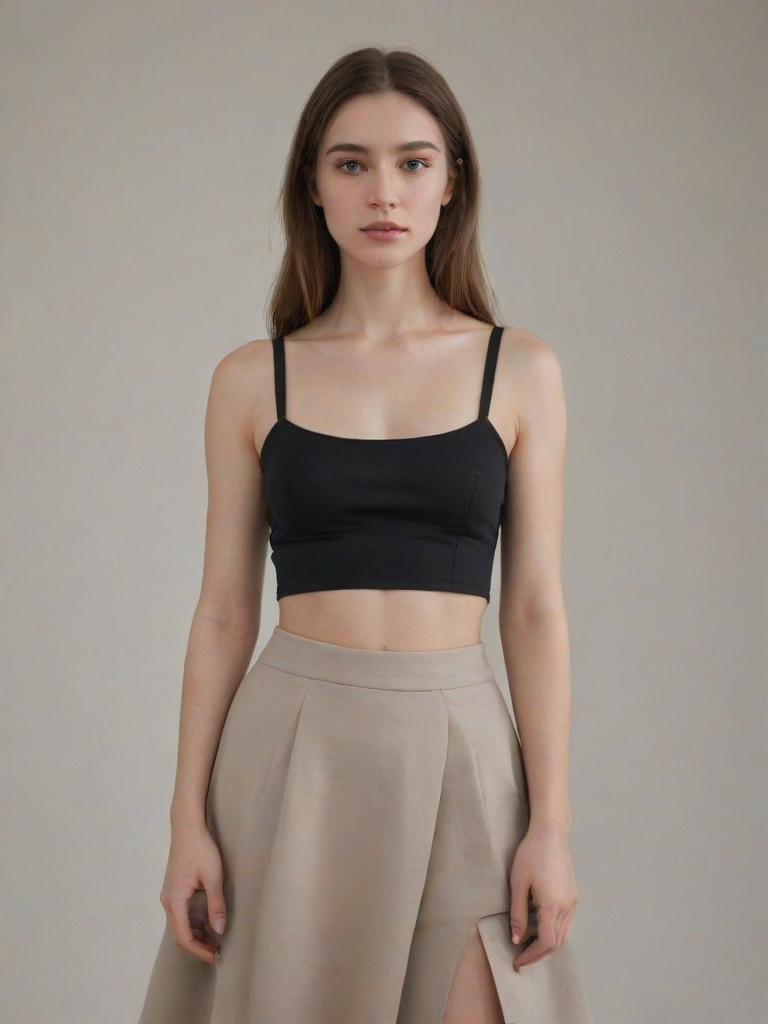

In [57]:
from IPython.display import display
from PIL import Image

display(Image.open(output_path))

In [ ]:
from pathlib import Path
import requests

PROJECT = Path(
    "/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/"
    "Piyu-AI-Clothing-Fashion-Design-Generator"
)

GENERATE_MODEL = PROJECT / "generate_model.py"

# GitHub raw file
URL = (
    "https://raw.githubusercontent.com/"
    "Piyu242005/"
    "AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/"
    "main/Piyu-AI-Clothing-Fashion-Design-Generator/generate_model.py"
)

response = requests.get(URL, timeout=60)

print("HTTP:", response.status_code)

if response.status_code != 200:
    print(response.text[:1000])
    raise RuntimeError("Could not download generate_model.py")

GENERATE_MODEL.write_text(
    response.text,
    encoding="utf-8"
)

code = GENERATE_MODEL.read_text(encoding="utf-8")

print("\nFirst 500 characters:\n")
print(code[:500])

print("\nChecks:")
print("auto1111sdk:", "auto1111sdk" in code)
print("Diffusers:", "StableDiffusionXLPipeline" in code)

In [ ]:
import sys
import importlib.util

sys.path.insert(0, str(PROJECT))

spec = importlib.util.spec_from_file_location(
    "generate_model",
    str(GENERATE_MODEL)
)

generate_model = importlib.util.module_from_spec(spec)
sys.modules["generate_model"] = generate_model

spec.loader.exec_module(generate_model)

print("✅ Correct generate_model.py loaded")

In [ ]:
# STEP 9 — Generate fashion model image

from IPython.display import display
from PIL import Image

output_path = PROJECT / "reference_images" / "fashion_model.png"

PROMPT = (
    "a photorealistic young male fashion model, centered full-body portrait, "
    "wearing a modern oversized black shirt with tailored black trousers, "
    "stylish contemporary fashion, natural skin texture, realistic face, "
    "realistic hands, detailed fabric texture, studio fashion photography, "
    "neutral dark background, soft professional lighting, sharp focus, "
    "high detail, premium fashion campaign, photorealistic"
)

generate_model.generate(
    clothing_type=PROMPT,
    output_path=str(output_path),
    steps=4,
    width=768,
    height=1024,
    guidance_scale=0.0,
)

print("✅ Generated:", output_path)

display(Image.open(output_path))

In [ ]:
from pathlib import Path
from IPython.display import display
from PIL import Image

# Correct project path
PROJECT = Path(
    "/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/"
    "Piyu-AI-Clothing-Fashion-Design-Generator"
)

# Generated image path
output_path = PROJECT / "reference_images" / "fashion_model.png"

# Check and display
if output_path.exists():
    print("✅ Generated:", output_path)
    display(Image.open(output_path))
else:
    print("❌ Image not found:")
    print(output_path)

In [ ]:
# Generate a human fashion model with RealVisXL
import subprocess, sys
from pathlib import Path
from PIL import Image
from IPython.display import display

# --- 1. Confirm you're in the right place ---
print("PROJECT:", PROJECT)
assert (PROJECT / "generate_model.py").exists(), "generate_model.py not found — check STEP 4 ran correctly."

# --- 2. Check GPU ---
gpu = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else "❌ No GPU detected.")

# --- 3. Run the model generator ---
MODEL_IMAGE = PROJECT / "reference_images" / "crop_top.png"
MODEL_IMAGE.parent.mkdir(parents=True, exist_ok=True)

PROMPT = "a realistic fashion model wearing a crop top and mini skirt"

cmd = [sys.executable, "generate_model.py",
       "--prompt", PROMPT,
       "--output_path", str(MODEL_IMAGE)]

print("\nRunning:", " ".join(cmd))
result = subprocess.run(cmd, cwd=str(PROJECT), capture_output=True, text=True)
print(result.stdout[-3000:])
if result.returncode != 0:
    print(result.stderr[-3000:])
    raise RuntimeError("generate_model.py failed — copy the error above and send it over.")

assert MODEL_IMAGE.exists(), "Model image was not created."
print("✅ Generated:", MODEL_IMAGE)

# --- 4. Display it ---
img = Image.open(MODEL_IMAGE).convert("RGB")
display(img)

## STEP 10 — Display the generated fashion model

In [ ]:
# STEP 10 — Display model
from IPython.display import display
from PIL import Image

model_img = Image.open(MODEL_IMAGE).convert("RGB")
print("Size:", model_img.size)
display(model_img)


## STEP 11 — SAM clothing segmentation

Pick 3 points **on the garment** in the image below (spread across different parts of it), then
enter their coordinates. This runs headless — no desktop GUI — using your `segment.py --points`
mode directly.

In [ ]:
# STEP 11A — Show coordinate grid to pick points from
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 12))
plt.imshow(model_img)
plt.xticks(range(0, model_img.width + 1, 100))
plt.yticks(range(0, model_img.height + 1, 100))
plt.grid(color="white", alpha=0.4)
plt.title("Pick 3 points INSIDE the clothing region")
plt.show()


In [ ]:
# STEP 11B — Enter 3 clothing points
points = []
default_points = [
    [model_img.width // 2, int(model_img.height * 0.35)],
    [int(model_img.width * 0.4), int(model_img.height * 0.45)],
    [int(model_img.width * 0.6), int(model_img.height * 0.55)],
]

for i in range(3):
    while True:
        try:
            raw = input(f"Point {i+1} (x,y) [Enter for default {default_points[i]}]: ").strip()
        except EOFError:
            raw = ""
        if raw == "":
            points.append(default_points[i])
            break
        try:
            x, y = [int(v.strip()) for v in raw.split(",")]
            if 0 <= x < model_img.width and 0 <= y < model_img.height:
                points.append([x, y])
                break
            print("❌ Point is outside the image.")
        except Exception:
            print("❌ Format must be like: 380,420")

print("Selected points:", points)


In [ ]:
# STEP 11C — Run SAM headlessly via your project's own segment.py
import subprocess, sys
from pathlib import Path

points_str = ",".join(str(v) for p in points for v in p)
MASK_PATH = MODEL_IMAGE.with_name(MODEL_IMAGE.stem + "_mask.jpg")  # matches segment.py's own naming

cmd = [sys.executable, "segment.py", "--input", str(MODEL_IMAGE), "--points", points_str]
print("Running:", " ".join(cmd))

result = subprocess.run(cmd, cwd=str(PROJECT), capture_output=True, text=True)
print(result.stdout[-2000:])
if result.returncode != 0:
    print(result.stderr[-3000:])
    raise RuntimeError("segment.py failed — see error above.")

assert MASK_PATH.exists(), f"Mask not created at expected path: {MASK_PATH}"
print("✅ Mask saved:", MASK_PATH)

# Free SAM's GPU memory now that the subprocess has exited
import torch, gc
gc.collect()
torch.cuda.empty_cache()


## STEP 12 — Display the mask (with overlay preview)

In [ ]:
# STEP 12 — Display mask + overlay on original
from PIL import Image
import matplotlib.pyplot as plt

mask_img = Image.open(MASK_PATH).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
axes[0].imshow(mask_img)
axes[0].set_title("Segmentation mask")
axes[0].axis("off")

axes[1].imshow(model_img)
axes[1].imshow(mask_img.convert("L"), cmap="jet", alpha=0.4)
axes[1].set_title("Mask overlay on model")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## STEP 13 — Upload the garment

In [ ]:
# STEP 13 — Upload garment image
from google.colab import files
from pathlib import Path
from shutil import copyfile

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No garment image uploaded.")

uploaded_name = next(iter(uploaded))
GARMENT_PATH = PROJECT / "samples" / "garment.png"
GARMENT_PATH.parent.mkdir(parents=True, exist_ok=True)
copyfile(uploaded_name, GARMENT_PATH)
print("✅ Saved:", GARMENT_PATH)


## STEP 14 — Display the garment

In [ ]:
# STEP 14 — Display garment
from IPython.display import display
from PIL import Image

garment_img = Image.open(GARMENT_PATH).convert("RGB")
print("Garment size:", garment_img.size)
display(garment_img)


## STEP 15 — IDM-VTON import re-check (right before the expensive run)

In [ ]:
# STEP 15 — Quick re-verification before running try_on.py
import subprocess, sys

test = subprocess.run(
    [sys.executable, "-c",
     "from src.tryon_pipeline import StableDiffusionXLInpaintPipeline; "
     "from src.unet_hacked_garmnet import UNet2DConditionModel; "
     "print('✅ IDM-VTON imports OK')"],
    cwd=str(IDM), capture_output=True, text=True,
)
print(test.stdout)
if test.returncode != 0:
    print(test.stderr[-2000:])
    raise RuntimeError("IDM-VTON import check failed right before inference — stopping here.")


## STEP 16 — Run virtual try-on

This step downloads the ~8–10 GB `yisol/idm_vton` SDXL pipeline the first time it runs (cached
afterwards), then runs 30 denoising steps at float16. Expect a few minutes on a T4.

In [ ]:
# STEP 16 — Run IDM-VTON
import os, subprocess, sys
from pathlib import Path

FINAL_IMAGE = PROJECT / "results" / "final_tryon.png"
FINAL_IMAGE.parent.mkdir(parents=True, exist_ok=True)
CLOTH_TYPE = "garment"  # short text description, e.g. "a black jacket" — improves the prompt

env = os.environ.copy()
env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
env["TOKENIZERS_PARALLELISM"] = "false"

cmd = [
    sys.executable, "try_on.py",
    "--reference_image", str(MODEL_IMAGE),
    "--mask", str(MASK_PATH),
    "--garment", str(GARMENT_PATH),
    "--cloth_type", CLOTH_TYPE,
    "--output_path", str(FINAL_IMAGE),
    "--denoise_steps", "30",
    "--seed", "42",
]

print("Running IDM-VTON (this takes a few minutes)...")
print(" ".join(cmd))
result = subprocess.run(cmd, cwd=str(IDM), env=env, capture_output=True, text=True)
print(result.stdout[-3000:])
if result.returncode != 0:
    print(result.stderr[-3000:])
    raise RuntimeError("try_on.py failed — see error above and check the troubleshooting section.")

assert FINAL_IMAGE.exists(), "IDM-VTON did not create the final image."
print("✅ Final image:", FINAL_IMAGE)


## STEP 17 — Display the final result

In [ ]:
# STEP 17 — Display final result + before/after comparison
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

final_img = Image.open(FINAL_IMAGE).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
axes[0].imshow(model_img); axes[0].set_title("Original model"); axes[0].axis("off")
axes[1].imshow(garment_img); axes[1].set_title("Garment"); axes[1].axis("off")
axes[2].imshow(final_img); axes[2].set_title("Try-on result"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## STEP 18 — Final output verification

In [ ]:
# STEP 18 — Verify expected files + optional zip for download
from pathlib import Path
import zipfile

expected = {
    "Fashion model": MODEL_IMAGE,
    "Clothing mask": MASK_PATH,
    "Garment": GARMENT_PATH,
    "Final try-on result": FINAL_IMAGE,
}

print(f"{'FILE':25} {'STATUS':10} PATH")
print("-" * 90)
all_present = True
for label, path in expected.items():
    ok = Path(path).exists()
    all_present &= ok
    print(f"{label:25} {'✅ OK' if ok else '❌ MISSING':10} {path}")

if all_present:
    zip_path = PROJECT / "results" / "piyu_fashion_run.zip"
    with zipfile.ZipFile(zip_path, "w") as zf:
        for path in expected.values():
            zf.write(path, arcname=Path(path).name)
    print("\n✅ All expected files present.")
    print("📦 Zipped for download:", zip_path)

    from google.colab import files as colab_files
    colab_files.download(str(zip_path))
else:
    print("\n❌ Some expected files are missing — re-run the failed step above.")


# ✅ Complete

**Expected files:**
```text
reference_images/fashion_model.png
reference_images/fashion_model_mask.jpg
samples/garment.png
results/final_tryon.png
results/piyu_fashion_run.zip
```

---

## Troubleshooting

**T4/L4 GPU not detected / `CUDA not available`**
Runtime → Change runtime type → Hardware accelerator → T4 GPU (or L4 on Colab Pro), then Runtime → Restart session and re-run from Step 1.

**CUDA out of memory**
Runtime → Restart session, then re-run from Step 4 (weights are already cached, downloads are skipped). Each stage already runs as its own subprocess, so memory doesn't accumulate across stages — OOM almost always means the single stage itself (usually IDM-VTON) needs more VRAM than the current GPU has. Try an A100 runtime (Colab Pro) if it persists.

**Hugging Face download fails / 401 Unauthorized**
Your model repo may have been switched to private. Get a token at https://huggingface.co/settings/tokens and set `os.environ["HF_TOKEN"]` before Step 6, or use Colab Secrets.

**`operator torchvision::nms does not exist`**
Step 2A should catch and repair this automatically. If it still happens later in the notebook, some other pip install after Step 2 silently changed Torch or Torchvision — check `pip list | grep torch` and re-run Step 2A.

**`ModuleNotFoundError: No module named 'src'`**
This means Step 5 didn't run, or `idm_vton/try_on.py` got deleted. Re-run Step 5 — it copies `try_on.py` into `idm_vton/`, which is required for its relative imports to resolve.

**SAM segmentation looks wrong / mask misses the garment**
Your 3 points need to be spread across different parts of the clothing (e.g., shoulder, chest, hem), not clustered in one spot. Re-run Step 11B with different coordinates.

**Detectron2 build fails in Step 3**
This is almost always a GCC/CUDA toolkit mismatch on the current Colab image. Runtime → Restart session and retry — Colab occasionally provisions a machine with a slightly different toolchain. If it fails twice, paste the last 30 lines of the error; it's usually one missing system package (`apt install build-essential`).


In [ ]:
!pip install -U huggingface_hub

In [ ]:
from huggingface_hub import login

login()

In [ ]:
BASE = "/content/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026/Piyu-AI-Clothing-Fashion-Design-Generator"

api.upload_file(
    path_or_fileobj=f"{BASE}/idm_vton/ckpt/humanparsing/parsing_atr.onnx",
    path_in_repo="idm_vton/humanparsing/parsing_atr.onnx",
    repo_id="Piyu2420/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026",
    repo_type="model"
)

api.upload_file(
    path_or_fileobj=f"{BASE}/idm_vton/ckpt/humanparsing/parsing_lip.onnx",
    path_in_repo="idm_vton/humanparsing/parsing_lip.onnx",
    repo_id="Piyu2420/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026",
    repo_type="model"
)

In [ ]:
api.upload_file(
    path_or_fileobj=f"{BASE}/idm_vton/ckpt/openpose/ckpts/body_pose_model.pth",
    path_in_repo="idm_vton/openpose/body_pose_model.pth",
    repo_id="Piyu2420/AI-Fashion-Design-Generator-IBM-INTERSHIP-2026",
    repo_type="model"
)